Imports

source /home/paul-hoheisel/vpr_env/bin/activate

In [37]:
from pathlib import Path
from hloc import extract_features, pairs_from_retrieval, match_features, reconstruction, localize_sfm
import pycolmap
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Optional: Falls du sichergehen willst, dass HLoc nicht doch die CPU nimmt:
torch.set_default_device(device)

import torch.multiprocessing as mp
import torch

# Dies muss vor JEDER anderen CUDA-Operation stehen
if __name__ == '__main__':
    try:
        mp.set_start_method('spawn', force=True)
        print("Spawn-Methode erfolgreich gesetzt.")
    except RuntimeError:
        print("Methode konnte nicht gesetzt werden (vielleicht schon initialisiert).")

# Sicherstellen, dass wir num_workers=0 wirklich überall haben
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Using device: cuda
Spawn-Methode erfolgreich gesetzt.
Device: cuda


Define paths

In [3]:
dataset_dir = Path('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria')
outputs = Path('outputs/oxford_hloc')

Configurations

In [4]:
feature_conf = extract_features.confs['superpoint_max'] # Local Features
retrieval_conf = extract_features.confs['netvlad']     # Global Features
matcher_conf = match_features.confs['superglue']       # Matcher

Select a scene and set output folder

In [5]:
scene_name = 'bodleian-library'
scene_dir = dataset_dir / scene_name
images_root = scene_dir / 'ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb'

scene_out = outputs / scene_name
scene_out.mkdir(parents=True, exist_ok=True)

Load image lists

In [12]:
list_dir = scene_dir / 'visual_reloc/imagelists'
db_list_path = list_dir / 'db_imagelist.txt'
query_day_path = list_dir / 'query_day_imagelist.txt'
query_night_path = list_dir / 'query_night_imagelist.txt'

def load_list(path):
    return [l.strip().split()[0] for l in open(path)]

db_list = [Path(p).name for p in load_list(db_list_path)]
query_day = load_list(query_day_path)
query_night = load_list(query_night_path)
query_day = [Path(p).name for p in query_day]
query_night = [Path(p).name for p in query_night]
all_queries = query_day + query_night


Extract features and perform Global Retrieval

In [15]:
#if 'loader' not in retrieval_conf:
#    retrieval_conf['loader'] = {}
#retrieval_conf['loader']['num_workers'] = 0


extract_features.main(retrieval_conf, images_root, image_list=db_list+all_queries, export_dir=scene_out) #change to scene_out
print("Global features saved in format: ", scene_out / f"{retrieval_conf['output']}.h5")
extract_features.main(feature_conf, images_root, image_list=db_list+all_queries, export_dir=scene_out)
print("Local features saved in format: ", scene_out / f"{feature_conf['output']}.h5")

[2026/04/20 13:41:44 hloc INFO] Extracting local features with configuration:
{'loader': {'num_workers': 0},
 'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 6760/6760 [06:22<00:00, 17.65it/s]
[2026/04/20 13:48:14 hloc INFO] Finished exporting features.
[2026/04/20 13:48:14 hloc INFO] Extracting local features with configuration:
{'loader': {'num_workers': 0},
 'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}


Global features saved in format:  outputs/oxford_hloc/bodleian-library/global-feats-netvlad.h5
Loaded SuperPoint model


/home/paul-hoheisel/Documents/SITD-setup-and-data/Hierarchical-Localization/hloc/extractors/../../third_party/SuperGluePretrainedNetwork/models/superpoint.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues rela

Local features saved in format:  outputs/oxford_hloc/bodleian-library/feats-superpoint-n4096-rmax1600.h5


In [16]:
loc_pairs = scene_out / 'pairs-query-netvlad50.txt'
pairs_from_retrieval.main(
    scene_out / f"{retrieval_conf['output']}.h5", 
    loc_pairs, 
    num_matched=50, 
    query_list=all_queries, 
    db_list=db_list
)

[2026/04/20 14:02:35 hloc INFO] Extracting image pairs from a retrieval database.
[2026/04/20 14:02:44 hloc INFO] Found 210900 pairs.


Matching (not necessary right now)

In [ ]:
match_features.main(matcher_conf, loc_pairs, feature_conf['output'], export_dir=scene_out)

print(f"Pipeline für {scene_name} abgeschlossen. Daten liegen in {scene_out}")

Evaluation:

(0) Create dictionary with poses for each picture

(1) First we want to reproduce the Coverage of Nighttime Queries Across Distance and Rotation Thresholds (Fig. 9) from the paper and additionally do that for the daytime queries

(0) Create dictionary with GT poses for each image, where image name is the key and pose is the value

In [ ]:
# don't need it 
from operator import gt

import numpy as np
from pathlib import Path

def load_gt_poses(colmap_text_path):
    images_txt = Path(colmap_text_path) / 'images.txt'
    poses = {}
    
    with open(images_txt, 'r') as f:
        lines = f.readlines()

    counter = 0
        
    # Skip the header lines (usually first 4 lines)
    for i in range(3, len(lines), 2):
        line = lines[i].strip().split()
        if not line: continue
        
        # Image name is the last element
        image_name = line[-1]
        image_name = Path(image_name).name  
        
        
        # Extract Quaternion (qw, qx, qy, qz)
        q = np.array(line[1:5], dtype=float)
        # Extract Translation (tx, ty, tz)
        t = np.array(line[5:8], dtype=float)

        poses[image_name] = {'q': q, 't': t}

        if counter < 3:  # Print the first loaded poses for verification
            print(f"Loading pose for image: {image_name}")
            print(f"  Rotation (Quat): {q}")
            print(f"  Translation: {t}")
            counter += 1
             # nur zum Debuggen
        
    return poses

# Usage
gt_path = Path('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/visual_reloc/colmap/text')
gt_poses = load_gt_poses(gt_path)

# Example: Get pose for a specific image
# Note: Ensure the name matches exactly as it appears in images.txt
test_img = 'vrs05_412347291475.jpg'
if test_img in gt_poses:
    print(f"Pose for {test_img}:")
    print(f"  Rotation (Quat): {gt_poses[test_img]['q']}")
    print(f"  Translation: {gt_poses[test_img]['t']}")
else:
    print(f"Image {test_img} not found in GT poses.")
print(list(gt_poses.keys()))
print(list(gt_poses.keys()).__len__())

Loading pose for image: vrs05_412347291475.jpg
  Rotation (Quat): [ 0.621794 -0.244625 -0.701851  0.246853]
  Translation: [ -7.46484  151.232672   1.1261  ]
Pose for vrs05_412347291475.jpg:
  Rotation (Quat): [ 0.621794 -0.244625 -0.701851  0.246853]
  Translation: [ -7.46484  151.232672   1.1261  ]
['vrs05_412347291475.jpg', 'vrs05_415847288675.jpg', 'vrs05_418347290850.jpg', 'vrs05_419597286850.jpg', 'vrs05_421097295475.jpg', 'vrs05_421847287100.jpg', 'vrs05_423347295137.jpg', 'vrs05_427597286300.jpg', 'vrs05_429097289550.jpg', 'vrs05_431097287850.jpg', 'vrs05_432847292762.jpg', 'vrs05_433847291975.jpg', 'vrs05_435597289137.jpg', 'vrs05_437847283975.jpg', 'vrs05_438347286975.jpg', 'vrs05_439847289262.jpg', 'vrs05_442597284350.jpg', 'vrs05_444097290925.jpg', 'vrs05_447847281600.jpg', 'vrs05_448597292350.jpg', 'vrs05_449847290850.jpg', 'vrs05_451347290887.jpg', 'vrs05_462347287887.jpg', 'vrs05_464847289012.jpg', 'vrs05_467347288425.jpg', 'vrs05_468597288637.jpg', 'vrs05_470347294262.j

Create "clean" arrays with image names without subfolder information


Create a dictionary with the clean image name as key and the pose as value:
1. function which takes the clean image name and returns the pose

In [27]:
transforms_path = Path('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/transforms.json')

import json
import numpy as np

def get_pose_dict(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    pose_dict = {}
    for frame in data['frames']:
        full_path = frame['file_path']
        clean_name = full_path.split('camera-rgb/')[-1]
        
        # Die 4x4 Matrix (Camera-to-World)
        matrix = np.array(frame['transform_matrix'])
        
        pose_dict[clean_name] = matrix
        
    return pose_dict

gt_dict = get_pose_dict(transforms_path)
print(f"GT dict sample: {list(gt_dict.items())[0]}")
print(f"GT dict length: {len(gt_dict)}")

GT dict sample: ('vrs00_1240390742950.jpg', array([[ 8.07978173e-02, -9.39345967e-01, -3.33317968e-01,
        -9.80034022e+01],
       [-3.56706042e-02, -3.36922190e-01,  9.40856549e-01,
        -1.15698406e+02],
       [-9.96092024e-01, -6.41295022e-02, -6.07296157e-02,
        -5.33097950e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]))
GT dict length: 41081


Reproduce paper's figure 9 by looking for nearest images
1. function for rotation angle between two frames

In [28]:
def calculate_rotation_angle(R_gt, R_est):
    """
    Berechnet den Winkelfehler in Grad zwischen zwei Rotationsmatrizen.
    """
    # 1. Relative Rotation berechnen
    # R_gt.T ist die Inverse, da Rotationsmatrizen orthogonal sind
    R_rel = np.dot(R_est, R_gt.T)
    
    # 2. Spur (Trace) der Matrix berechnen
    trace = np.trace(R_rel)
    
    # 3. Argument für arccos clippen (wichtig wegen numerischer Rundungsfehler!)
    # Ohne clip(-1, 1) kann es bei identischen Matrizen zu NaN führen
    arg = (trace - 1.0) / 2.0
    phi_rad = np.arccos(np.clip(arg, -1.0, 1.0))
    
    # 4. In Grad umrechnen
    return np.rad2deg(phi_rad)

2. function with image name, translation and angle threshold -> output: presence of db image inside threshold

In [29]:
def is_close(img_name, translation_threshold, angle_threshold):
    img_translation = gt_dict[img_name][:3, 3]  # Extrahiere die Translation
    img_rotation = gt_dict[img_name][:3, :3]    # Extrahire die Rotation (3x3 Teil der Matrix)
    for db_img in db_list:
        db_translation = gt_dict[db_img][:3, 3]
        db_rotation = gt_dict[db_img][:3, :3]
        
        # Berechne Translation Error
        translation_error = np.linalg.norm(img_translation - db_translation)
        
        # Berechne Rotation Error
        rotation_error = calculate_rotation_angle(img_rotation, db_rotation)
        
        if translation_error < translation_threshold and rotation_error < angle_threshold:
            return True


In [47]:
def get_distance_between_poses(img_name, db_img_name):
    img_translation = gt_dict[img_name][:3, 3]  # Extrahiere die Translation
    
    db_translation = gt_dict[db_img_name][:3, 3]
    
    # Berechne Translation Error
    distance = np.linalg.norm(img_translation - db_translation)

    return distance

3. Create a dictionary with key being the image name and value being a list of the paired image names

In [42]:
pair_dict = {}
pairs = (loc_pairs).read_text().strip().split('\n')
counter = 0
for pair_line in pairs:
    query, db = pair_line.split()
    if query not in pair_dict.keys():
        pair_dict[query] = []
    pair_dict[query].append(db)

4. Create pandas dataframe 

In [ ]:
# do not execute
closest_gt = 10.0
for db_img in db_list:
    distance = get_distance_between_poses(img, db_img)
    if distance <= closest_gt - 1.0:
        angle = calculate_rotation_angle(gt_dict[img][:3, :3], gt_dict[db_img][:3, :3])
        if angle < (closest_gt - 1) * 10:
            closest_gt = int(max(np.ceil(distance), np.ceil(angle / 10)))
            if closest_gt == 1:
                break
vpr_closest_found = 10.0
count_close_50 = 0
count_close_90 = 0
for pair_img in pair_dict[img]:
    distance = get_distance_between_poses(img, pair_img)
    angle = calculate_rotation_angle(gt_dict[img][:3, :3], gt_dict[pair_img][:3, :3])
    if distance <= 5.0 and angle < 50.0:
        count_close_50 += 1
    if distance <= 9.0 and angle < 90.0:
        count_close_90 += 1
    if distance <= vpr_closest_found - 1.0:
        if angle < (vpr_closest_found - 1) * 10:
            vpr_closest_found = int(max(np.ceil(distance), np.ceil(angle / 10)))
vpr_closest_found = (vpr_closest_found == closest_gt)
vpr_top1_dist = get_distance_between_poses(img, pair_dict[img][0])
vpr_avg_dist_top5 = np.mean([get_distance_between_poses(img, pair_img) for pair_img in pair_dict[img][:5]])
precision_top50_5m = count_close_50 / 50
precision_top50_9m = count_close_90 / 50

print("distance of top 5 VPR matches: ", [get_distance_between_poses(img, pair_img) for pair_img in pair_dict[img][:5]])

print(f"Image: {img}, Closest GT: {closest_gt}, VPR Closest Found: {vpr_closest_found}, VPR Top1 Dist: {vpr_top1_dist:.2f}, VPR Avg Dist Top5: {vpr_avg_dist_top5:.2f},, count_close_50: {count_close_50}, count_close_90: {count_close_90}")

distance of top 5 VPR matches:  [np.float64(5.324842684168817), np.float64(3.4727959375471595), np.float64(3.6569664356018565), np.float64(3.341391927662873), np.float64(16.961639604432108)]
Image: vrs05_424347285475.jpg, Closest GT: 3, VPR Closest Found: True, VPR Top1 Dist: 5.32, VPR Avg Dist Top5: 6.55,, count_close_50: 0.16, count_close_90: 0.3


In [ ]:
data = pd.DataFrame(columns=['img_name', 'split', 'closest_gt', 'vpr_closest_found', 'vpr_found_gt', 'vpr_top1_dist', 'vpr_avg_dist_top5', 'precision_top50_5m', 'precision_top50_9m'])

for split in ['day', 'night']: 
    if split == 'day':
        query_list = query_day
    else:
        query_list = query_night

    for img in query_list:
        min_distance = float('inf')
        closest_gt = 10
        for db_img in db_list:
            distance = get_distance_between_poses(img, db_img)
            if distance < min_distance:
                min_distance = distance

            if distance <= closest_gt - 1.0:
                angle = calculate_rotation_angle(gt_dict[img][:3, :3], gt_dict[db_img][:3, :3])
                if angle <= (closest_gt - 1) * 10:
                    closest_gt = int(max(np.ceil(distance), np.ceil(angle / 10)))
        vpr_closest_found = 10.0
        count_close_5 = 0
        count_close_9 = 0
        count_close_10 = 0
        vpr_closest_distance = float('inf')
        for pair_img in pair_dict[img]:
            distance = get_distance_between_poses(img, pair_img)
            angle = calculate_rotation_angle(gt_dict[img][:3, :3], gt_dict[pair_img][:3, :3])
            if distance < vpr_closest_distance:
                vpr_closest_distance = distance
            if distance <= 5.0 and angle < 10.0:
                count_close_5 += 1
            if distance <= 9.0 and angle < 90.0:
                count_close_9 += 1
            if distance <= 10.0 and angle < 25.0:
                count_close_10 += 1

            if distance <= vpr_closest_found - 1.0:
                if angle < (vpr_closest_found - 1) * 10:
                    vpr_closest_found = int(max(np.ceil(distance), np.ceil(angle / 10)))
        vpr_found_gt = (vpr_closest_found == closest_gt)
        vpr_top1_dist = get_distance_between_poses(img, pair_dict[img][0])
        vpr_avg_dist_top5 = np.mean([get_distance_between_poses(img, pair_img) for pair_img in pair_dict[img][:5]])
        precision_top50_5m = count_close_50 / 50
        precision_top50_9m = count_close_90 / 50
        precision_top50_10m = count_close_10 / 50

        data = pd.concat([data, pd.DataFrame([{'img_name': img, 'split': split, 'closest_gt_distance': min_distance, 
                                               'closest_gt': closest_gt, 'vpr_closest_found': vpr_closest_found, 'vpr_closest_distance': vpr_closest_distance, 
                                               'vpr_found_gt': vpr_found_gt, 'vpr_top1_dist': vpr_top1_dist, 'vpr_avg_dist_top5': vpr_avg_dist_top5, 
                                               'precision_top50_5m_10degrees': precision_top50_5m, 'precision_top50_9m_90degrees': precision_top50_9m, 'precision_top50_10m_25degrees': precision_top50_10m}])], ignore_index=True)

In [164]:
data[(data['split'] == 'day') & (data['closest_gt'] == 2)]['precision_top50_10m_25degrees'].mean()

np.float64(0.16352059925093634)

In [137]:
print(len(query_day), len(query_night), len(db_list))

1310 2908 2542


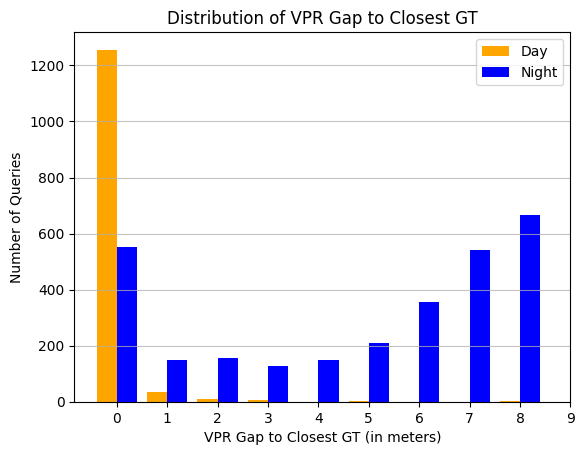

In [165]:
# VPR efficiency
data['vpr_gap_to_db'] = data['vpr_closest_found'] - data['closest_gt']
# histogram of vpr_gap_to_db comparing day and night queries
import matplotlib.pyplot as plt
plt.hist([data[(data['split'] == 'day') & (data['vpr_gap_to_db'] >= 0)]['vpr_gap_to_db'], 
         data[(data['split'] == 'night') & (data['vpr_gap_to_db'] >= 0)]['vpr_gap_to_db']],
         bins=np.arange(0, 10, 1), align='left', rwidth=0.8, color=['orange', 'blue'], label=['Day', 'Night'])
plt.xlabel('VPR Gap to Closest GT (in meters)')
plt.ylabel('Number of Queries')
plt.title('Distribution of VPR Gap to Closest GT')
plt.xticks(np.arange(0, 10, 1))
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

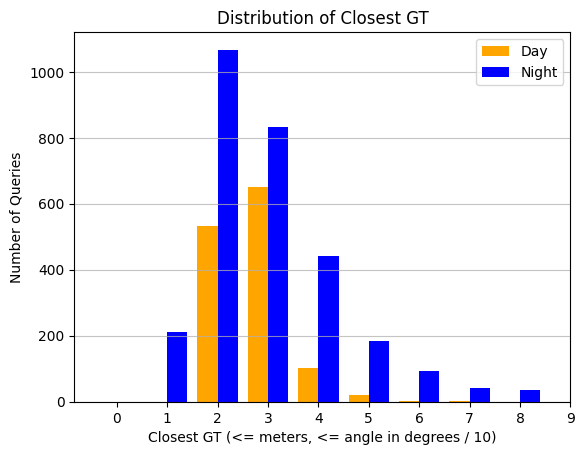

In [166]:
# histogram of closest_gt comparing day and night queries
plt.hist([data[data['split'] == 'day']['closest_gt'], data[data['split'] == 'night']['closest_gt']], bins=np.arange(0, 10, 1), align='left', rwidth=0.8, color=['orange', 'blue'], label=['Day', 'Night'])
plt.xlabel('Closest GT (<= meters, <= angle in degrees / 10)')
plt.ylabel('Number of Queries')
plt.title('Distribution of Closest GT')
plt.xticks(np.arange(0, 10, 1))
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

In [ ]:
# logistic regression to predict vpr_found_gt based on split, closest_gt_distance, closest_gt 
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X = data[['split', 'closest_gt_distance', 'closest_gt']]
X['split'] = X['split'].map({'day': 0, 'night': 1})
y = data['vpr_found_gt'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# interpret coefficients
print("Logistic Regression Coefficients:")
print(f"Split (Night vs Day): {model.coef_[0][0]:.4f}")
print(f"Closest GT Distance: {model.coef_[0][1]:.4f}")
print(f"Closest GT: {model.coef_[0][2]:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
# perform linear regression to predict avg distance of top 5 VPR matches based on split, closest_gt_distance, closest_gt
from sklearn.linear_model import LinearRegression
X = data[['split', 'closest_gt_distance', 'closest_gt']]
X['split'] = X['split'].map({'day': 0, 'night': 1})
y = data['vpr_avg_dist_top5']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Linear Regression Coefficients:")
print(f"Split (Night vs Day): {model.coef_[0]:.4f}")
print(f"Closest GT Distance: {model.coef_[1]:.4f}")
print(f"Closest GT: {model.coef_[2]:.4f}")
print("\nR^2 Score:", model.score(X_test, y_test))
# show p values for linear regression coefficients
import statsmodels.api as sm
X = data[['split', 'closest_gt_distance', 'closest_gt']]
X['split'] = X['split'].map({'day': 0, 'night': 1})
y = data['vpr_avg_dist_top5']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

In [99]:
print(data[data['split'] == 'day']['closest_gt'].value_counts().sort_index())
print(data[data['split'] == 'night']['closest_gt'].value_counts().sort_index())

closest_gt
2    534
3    651
4    101
5     20
6      3
7      1
Name: count, dtype: int64
closest_gt
1      210
2     1067
3      832
4      442
5      184
6       93
7       41
8       34
9        1
10       4
Name: count, dtype: int64


Investigate, if the predicted pairs are better for gt distance 2 compared to 3 or 4.
Metrics:
- vpr_avg_dist_top5 (50 degrees)
- precision_top50_9m (90 degrees)
- precision_top50_25m (and 90 degrees)
- vpr_found_gt
- vpr_closest_found <= 9m (and 90 degrees)


In [180]:
# data is only significant for closest_gt 2,3,4 for day and 1,2,3,4,5,6 for night
data['vpr_closer_than_9m'] = (data['vpr_closest_distance'] <= 9.0).astype(int)
for i in range(1, 11):
    subset = data[data['closest_gt'] == i]
    print(f"Closest GT = {i}:")
    print(f"  Day queries: {subset[subset['split'] == 'day']['vpr_found_gt'].mean():.2f} found GT, Avg VPR Top5 Dist: {subset[subset['split'] == 'day']
            ['vpr_avg_dist_top5'].mean():.2f}, precision_top50_25m: {subset[subset['split'] == 'day']['precision_top50_10m_25degrees'].mean():.2f}, precision_top50_9m: {subset[subset['split'] == 'day']['precision_top50_9m_90degrees'].mean():.2f}, vpr_closer_than_9m: {subset[subset['split'] == 'day']['vpr_closer_than_9m'].mean():.2f}")
    print(f"  Night queries: {subset[subset['split'] == 'night']['vpr_found_gt'].mean():.2f} found GT, Avg VPR Top5 Dist: {subset[subset['split'] == 'night']
            ['vpr_avg_dist_top5'].mean():.2f}, precision_top50_25m: {subset[subset['split'] == 'night']['precision_top50_10m_25degrees'].mean():.2f}, precision_top50_9m: {subset[subset['split'] == 'night']['precision_top50_9m_90degrees'].mean():.2f}, vpr_closer_than_9m: {subset[subset['split'] == 'night']['vpr_closer_than_9m'].mean():.2f}")

Closest GT = 1:
  Day queries: nan found GT, Avg VPR Top5 Dist: nan, precision_top50_25m: nan, precision_top50_9m: nan, vpr_closer_than_9m: nan
  Night queries: 0.28 found GT, Avg VPR Top5 Dist: 80.48, precision_top50_25m: 0.03, precision_top50_9m: 0.04, vpr_closer_than_9m: 0.62
Closest GT = 2:
  Day queries: 0.96 found GT, Avg VPR Top5 Dist: 8.05, precision_top50_25m: 0.16, precision_top50_9m: 0.24, vpr_closer_than_9m: 1.00
  Night queries: 0.25 found GT, Avg VPR Top5 Dist: 74.95, precision_top50_25m: 0.03, precision_top50_9m: 0.04, vpr_closer_than_9m: 0.65
Closest GT = 3:
  Day queries: 0.96 found GT, Avg VPR Top5 Dist: 9.32, precision_top50_25m: 0.12, precision_top50_9m: 0.22, vpr_closer_than_9m: 1.00
  Night queries: 0.18 found GT, Avg VPR Top5 Dist: 81.26, precision_top50_25m: 0.02, precision_top50_9m: 0.03, vpr_closer_than_9m: 0.55
Closest GT = 4:
  Day queries: 0.96 found GT, Avg VPR Top5 Dist: 17.46, precision_top50_25m: 0.07, precision_top50_9m: 0.18, vpr_closer_than_9m: 1.00


Explanation of variables:

x-axis:
- closest_gt ("viewpoint variability"): closest database image is inside <= meters and <= 10i degrees of rotation relative to the query

y-axis:
- vpr_found_gt: A boolean indicator specifying whether at least one image within the Top-50 retrieved results satisfies the ground truth threshold of ≤i meters and ≤10i degrees of rotation relative to the query image.
- vpr_avg_dist_top5: The average Euclidean distance, measured in meters, between the ground truth position of the query and the ground truth positions of the five highest-ranked retrieved images.
- precision_top50_9m: The proportion of images within the Top-50 retrieved set that are located within a 9-meter radius of the query's ground truth position and within 90 degrees of rotation.
- precision_top50_25m: The proportion of images within the Top-50 retrieved set that are located within a 25-meter radius of the query's ground truth position and within 90 degrees of rotation.
- vpr_closer_than_9m: A boolean indicator that is true if at least one image in the Top-50 retrieved results is located within a 9-meter radius of the query's ground truth position, regardless of the specific ""Closest GT"" label."


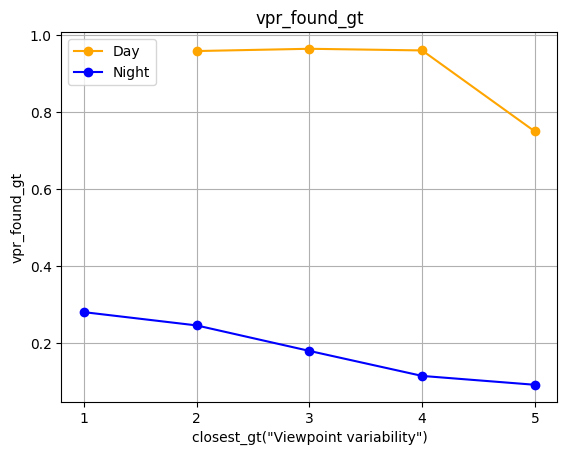

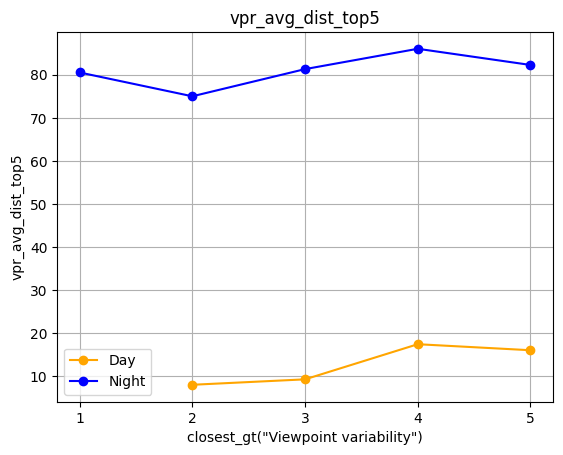

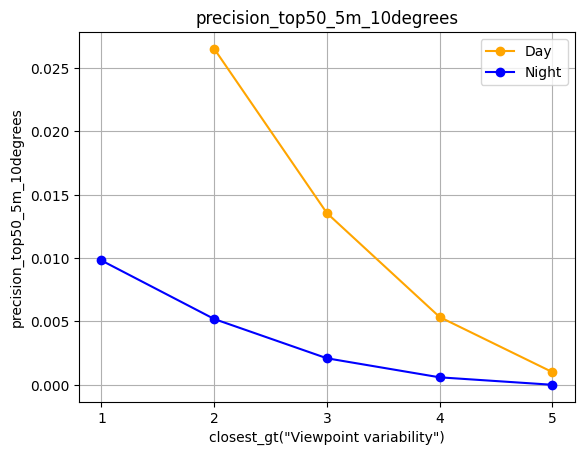

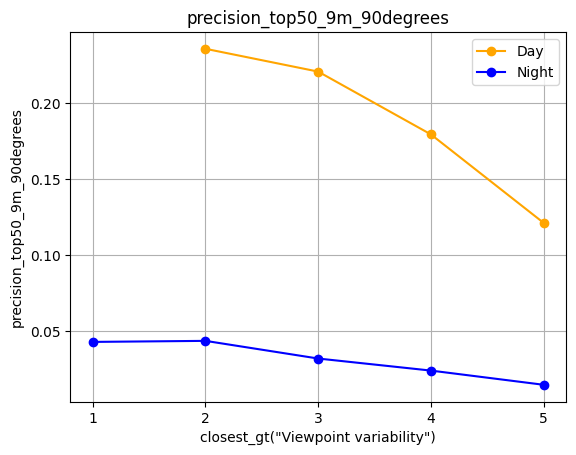

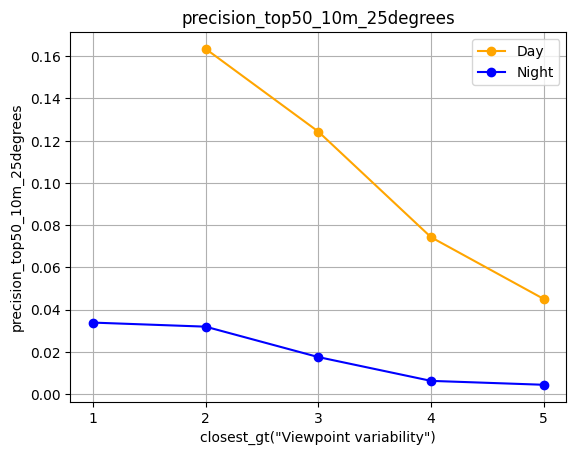

In [167]:
# plot variable versus closest_gt
start, end = 1, 6 # end exclusive
for var in ['vpr_found_gt', 'vpr_avg_dist_top5', 'precision_top50_5m_10degrees', 'precision_top50_9m_90degrees', 'precision_top50_10m_25degrees']:
    y = np.zeros((end - start, 2))  # 2 for day and night
    for i in range(start, end):
        subset = data[data['closest_gt'] == i]
        day_mean = subset[subset['split'] == 'day'][var].mean()
        night_mean = subset[subset['split'] == 'night'][var].mean()
        y[i - start, 0] = day_mean
        y[i - start, 1] = night_mean
    plt.figure()
    plt.plot(range(start, end), y[:, 0], label='Day', marker='o', color='orange')
    plt.plot(range(start, end), y[:, 1], label='Night', marker='o', color='blue')
    plt.xlabel('closest_gt("Viewpoint variability")')
    plt.ylabel(var)
    plt.title(f'{var}')
    plt.xticks(range(start, end))
    plt.grid()
    plt.legend()
    plt.show()

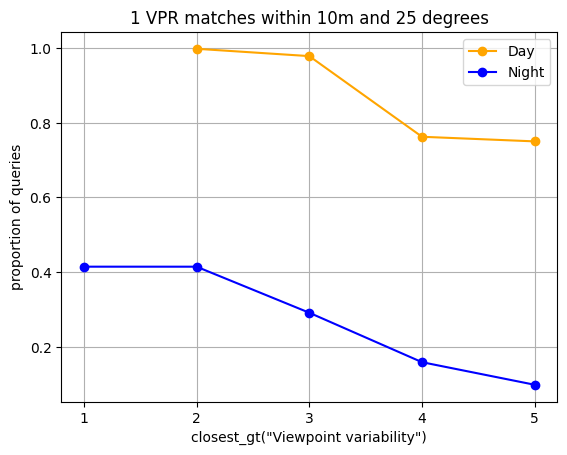

[[       nan 0.41428571]
 [0.99812734 0.41424555]
 [0.97849462 0.29086538]
 [0.76237624 0.15837104]
 [0.75       0.09782609]]


In [181]:
# compute how many queries get at least k VPR matches within 9m and 90 degrees
k = 1
distance = 10
degree = 25
variable = f'precision_top50_{distance}m_{degree}degrees'
for i in range(start, end):
    subset = data[data['closest_gt'] == i]
    if i == 1:
        day_matches = None
    else:
        day_matches = subset[(subset['split'] == 'day') & (subset[variable] >= k/50)].shape[0] / subset[subset['split'] == 'day'].shape[0]
    night_matches = subset[(subset['split'] == 'night') & (subset[variable] >= k/50)].shape[0] / subset[subset['split'] == 'night'].shape[0]
    y[i - start, 0] = day_matches
    y[i - start, 1] = night_matches
plt.figure()
plt.plot(range(start, end), y[:, 0], label='Day', marker='o', color='orange')
plt.plot(range(start, end), y[:, 1], label='Night', marker='o', color='blue')
plt.xlabel('closest_gt("Viewpoint variability")')
plt.ylabel('proportion of queries')
plt.title(f'{k} VPR matches within {distance}m and {degree} degrees')
plt.xticks(range(start, end))
plt.grid()
plt.legend()
plt.show()
print(y)

In [135]:
csv_path = '/home/paul-hoheisel/Documents/Research results/bodelian-library/'
data.to_csv(csv_path + 'results_bodelian.csv', index=False)

In [75]:
print(f'close db picture was found at night: {data[data["split"] == "night"]["vpr_found_gt"].mean():.2f}')
print(f'close db picture was found at day: {data[data["split"] == "day"]["vpr_found_gt"].mean():.2f}')
data[data['split'] == 'night']['closest_gt'].value_counts().sort_index()

close db picture was found at night: 0.19
close db picture was found at day: 0.96


closest_gt
1      210
2     1067
3      832
4      442
5      184
6       93
7       41
8       34
9        1
10       4
Name: count, dtype: int64

DAY QUERIES STATISTICS
       vpr_found_gt  vpr_top1_dist  vpr_avg_dist_top5  precision_top50_5m  \
count          1310    1310.000000        1310.000000             1310.00   
unique            2    1310.000000        1310.000000               18.00   
top            True       5.324843           6.551527                0.08   
freq           1256       1.000000           1.000000              192.00   

        precision_top50_9m  
count              1310.00  
unique               31.00  
top                   0.16  
freq                114.00  

NIGHT QUERIES STATISTICS
       vpr_found_gt  vpr_top1_dist  vpr_avg_dist_top5  precision_top50_5m  \
count          2908    2908.000000        2908.000000              2908.0   
unique            2    2908.000000        2908.000000                13.0   
top           False       8.482695          59.489378                 0.0   
freq           2356       1.000000           1.000000              2098.0   

        precision_top50_9m  
count

/tmp/ipykernel_5904/3980864875.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([day_stats['vpr_top1_dist'], night_stats['vpr_top1_dist']], labels=['Day', 'Night'])
/tmp/ipykernel_5904/3980864875.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([day_stats['vpr_avg_dist_top5'], night_stats['vpr_avg_dist_top5']], labels=['Day', 'Night'])
/tmp/ipykernel_5904/3980864875.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot([day_stats['closest_gt'], night_stats['closest_gt']], labels=['Day', 'Night'])


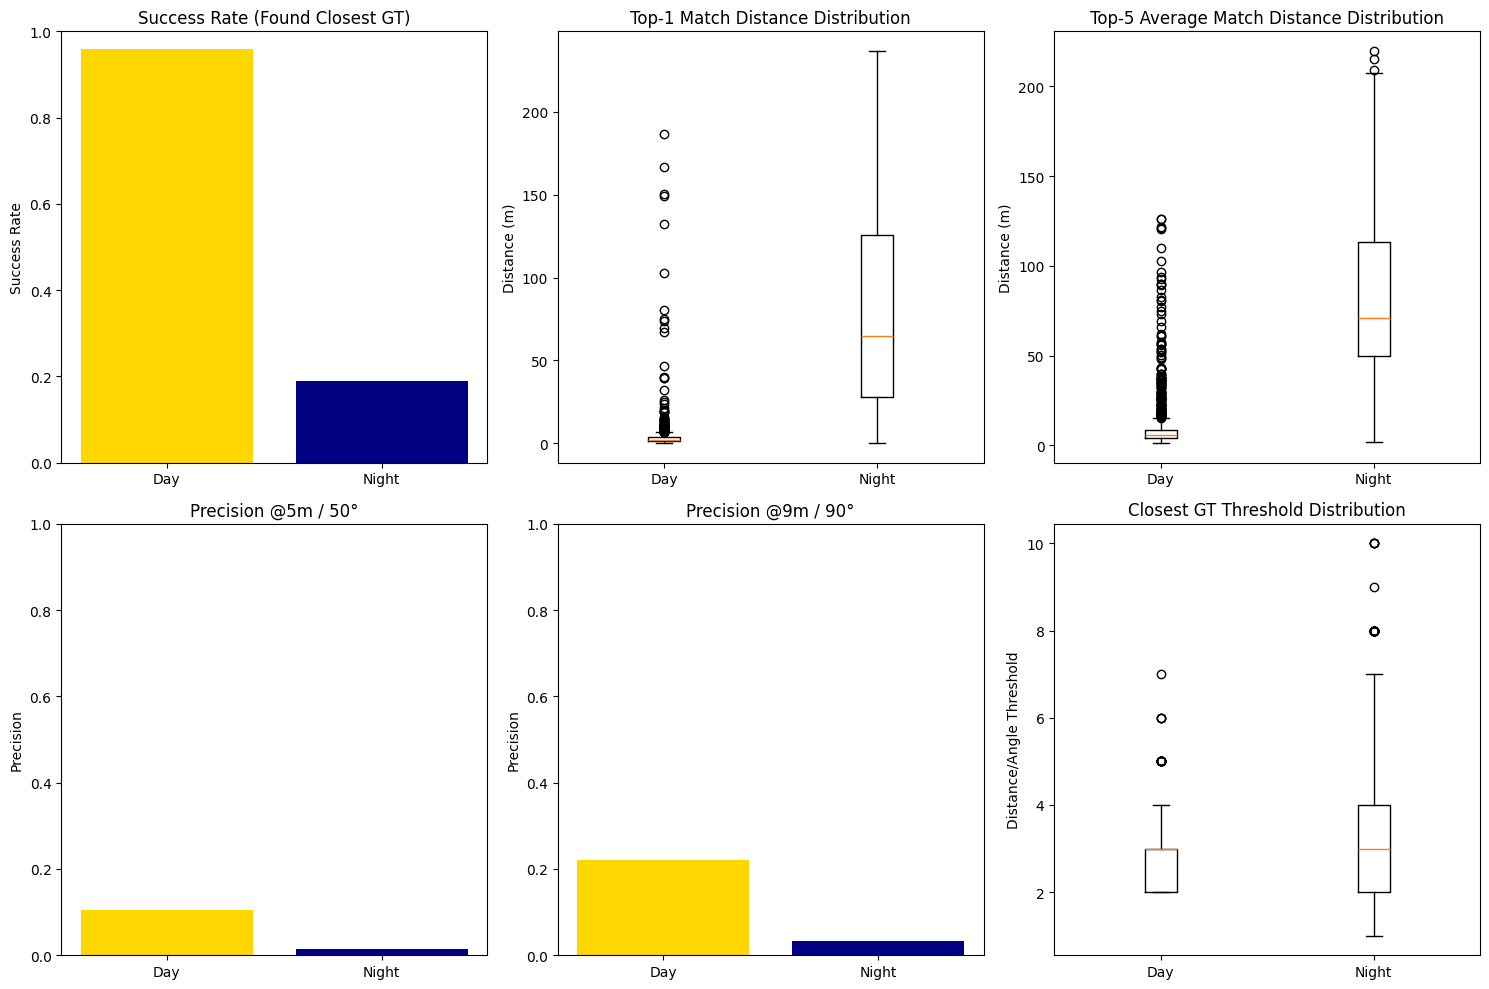


Visualization saved as 'day_night_comparison.png'

FAILURE CASE ANALYSIS
Day failures: 54 (4.1%)
Night failures: 2356 (81.0%)

Day failure cases - Avg Top1 Distance: 11.17m
Night failure cases - Avg Top1 Distance: 86.39m


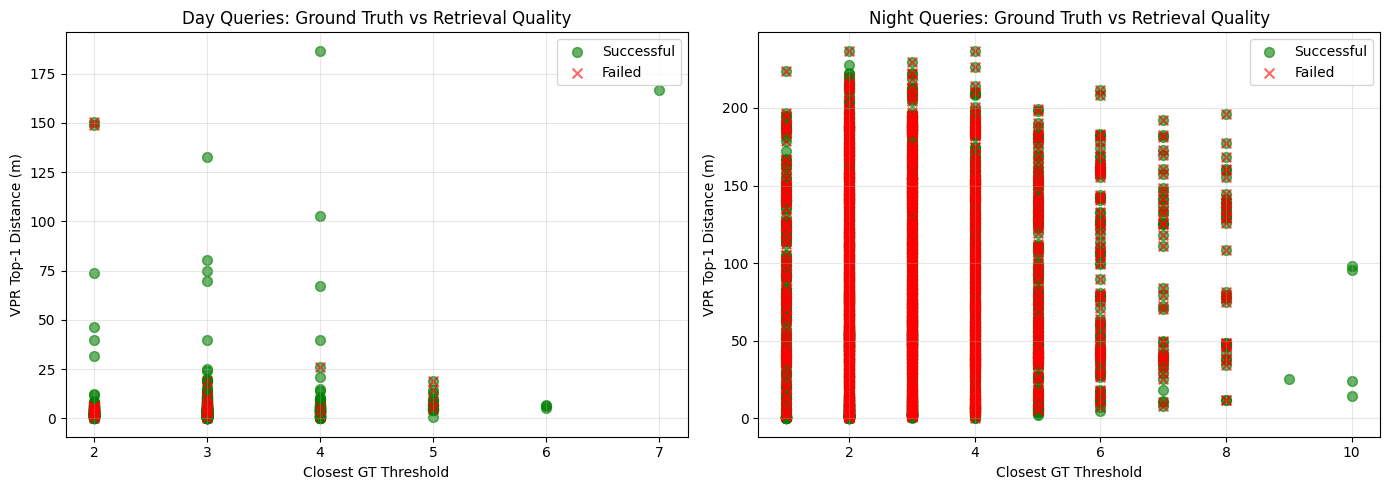


Failure analysis visualization saved as 'failure_analysis.png'


In [69]:
# Calculate some stats to see difference between day and night queries

day_stats = data[data['split'] == 'day']
night_stats = data[data['split'] == 'night']

# Basic statistics
print("=" * 60)
print("DAY QUERIES STATISTICS")
print("=" * 60)
print(day_stats[['vpr_found_gt', 'vpr_top1_dist', 'vpr_avg_dist_top5', 'precision_top50_5m', 'precision_top50_9m']].describe())

print("\n" + "=" * 60)
print("NIGHT QUERIES STATISTICS")
print("=" * 60)
print(night_stats[['vpr_found_gt', 'vpr_top1_dist', 'vpr_avg_dist_top5', 'precision_top50_5m', 'precision_top50_9m']].describe())

# Comparison metrics
print("\n" + "=" * 60)
print("COMPARISON: DAY vs NIGHT")
print("=" * 60)
print(f"Success Rate (found closest GT in top 50): Day={day_stats['vpr_found_gt'].mean():.2%}, Night={night_stats['vpr_found_gt'].mean():.2%}")
print(f"Avg Top1 Distance: Day={day_stats['vpr_top1_dist'].mean():.2f}m, Night={night_stats['vpr_top1_dist'].mean():.2f}m")
print(f"Avg Top5 Distance: Day={day_stats['vpr_avg_dist_top5'].mean():.2f}m, Night={night_stats['vpr_avg_dist_top5'].mean():.2f}m")
print(f"Precision @5m/50deg: Day={day_stats['precision_top50_5m'].mean():.2%}, Night={night_stats['precision_top50_5m'].mean():.2%}")
print(f"Precision @9m/90deg: Day={day_stats['precision_top50_9m'].mean():.2%}, Night={night_stats['precision_top50_9m'].mean():.2%}")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Success Rate Comparison
axes[0, 0].bar(['Day', 'Night'], [day_stats['vpr_found_gt'].mean(), night_stats['vpr_found_gt'].mean()], color=['gold', 'navy'])
axes[0, 0].set_ylabel('Success Rate')
axes[0, 0].set_title('Success Rate (Found Closest GT)')
axes[0, 0].set_ylim([0, 1])

# Plot 2: Top1 Distance Distribution
axes[0, 1].boxplot([day_stats['vpr_top1_dist'], night_stats['vpr_top1_dist']], labels=['Day', 'Night'])
axes[0, 1].set_ylabel('Distance (m)')
axes[0, 1].set_title('Top-1 Match Distance Distribution')

# Plot 3: Top5 Average Distance
axes[0, 2].boxplot([day_stats['vpr_avg_dist_top5'], night_stats['vpr_avg_dist_top5']], labels=['Day', 'Night'])
axes[0, 2].set_ylabel('Distance (m)')
axes[0, 2].set_title('Top-5 Average Match Distance Distribution')

# Plot 4: Precision @5m/50deg
axes[1, 0].bar(['Day', 'Night'], [day_stats['precision_top50_5m'].mean(), night_stats['precision_top50_5m'].mean()], color=['gold', 'navy'])
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision @5m / 50°')
axes[1, 0].set_ylim([0, 1])

# Plot 5: Precision @9m/90deg
axes[1, 1].bar(['Day', 'Night'], [day_stats['precision_top50_9m'].mean(), night_stats['precision_top50_9m'].mean()], color=['gold', 'navy'])
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision @9m / 90°')
axes[1, 1].set_ylim([0, 1])

# Plot 6: Closest GT Distance
axes[1, 2].boxplot([day_stats['closest_gt'], night_stats['closest_gt']], labels=['Day', 'Night'])
axes[1, 2].set_ylabel('Distance/Angle Threshold')
axes[1, 2].set_title('Closest GT Threshold Distribution')

plt.tight_layout()
plt.savefig('day_night_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'day_night_comparison.png'")

# Failure case analysis
print("\n" + "=" * 60)
print("FAILURE CASE ANALYSIS")
print("=" * 60)

day_failures = day_stats[day_stats['vpr_found_gt'] == False]
night_failures = night_stats[night_stats['vpr_found_gt'] == False]

print(f"Day failures: {len(day_failures)} ({len(day_failures)/len(day_stats):.1%})")
print(f"Night failures: {len(night_failures)} ({len(night_failures)/len(night_stats):.1%})")

if len(day_failures) > 0:
    print(f"\nDay failure cases - Avg Top1 Distance: {day_failures['vpr_top1_dist'].mean():.2f}m")
if len(night_failures) > 0:
    print(f"Night failure cases - Avg Top1 Distance: {night_failures['vpr_top1_dist'].mean():.2f}m")

# Scatter plot: Closest GT vs VPR Found Distance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(day_stats['closest_gt'], day_stats['vpr_top1_dist'], alpha=0.6, s=50, label='Successful', color='green')
axes[0].scatter(day_failures['closest_gt'], day_failures['vpr_top1_dist'], alpha=0.6, s=50, label='Failed', color='red', marker='x')
axes[0].set_xlabel('Closest GT Threshold')
axes[0].set_ylabel('VPR Top-1 Distance (m)')
axes[0].set_title('Day Queries: Ground Truth vs Retrieval Quality')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(night_stats['closest_gt'], night_stats['vpr_top1_dist'], alpha=0.6, s=50, label='Successful', color='green')
axes[1].scatter(night_failures['closest_gt'], night_failures['vpr_top1_dist'], alpha=0.6, s=50, label='Failed', color='red', marker='x')
axes[1].set_xlabel('Closest GT Threshold')
axes[1].set_ylabel('VPR Top-1 Distance (m)')
axes[1].set_title('Night Queries: Ground Truth vs Retrieval Quality')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFailure analysis visualization saved as 'failure_analysis.png'")


In [30]:
# calculate how many images from the night queries are close to a db image with translation threshold of 1.0m and angle threshold of 10 degrees and save the percentage
translation_threshold = 1.0  # 1 Meter
angle_threshold = 10.0       # 10 Grad
close_count = 0
for img in query_night:
    if is_close(img, translation_threshold, angle_threshold):
        close_count += 1

percentage = (close_count / len(query_night)) * 100
print(f"Percentage of close images: {percentage:.2f}%")

Percentage of close images: 7.22%


In [ ]:
# do the same for 2.0m and 20 degrees, 3.0m and 30 degrees, ... , 9.0m and 90 degrees
for t in range(1, 10):
    translation_threshold = t * 1.0  # t Meter
    angle_threshold = t * 10.0       # t*10 Grad
    close_count = 0
    for img in query_day:
        if is_close(img, translation_threshold, angle_threshold):
            close_count += 1

    percentage = (close_count / len(query_day)) * 100
    print(f"Threshold: {translation_threshold:.1f}m & {angle_threshold:.1f}° - Percentage of close images: {percentage:.2f}%")

Threshold: 1.0m & 10.0° - Percentage of close images: 0.00%
Threshold: 2.0m & 20.0° - Percentage of close images: 40.76%
Threshold: 3.0m & 30.0° - Percentage of close images: 90.46%
Threshold: 4.0m & 40.0° - Percentage of close images: 98.17%
Threshold: 5.0m & 50.0° - Percentage of close images: 99.69%
Threshold: 6.0m & 60.0° - Percentage of close images: 99.92%
Threshold: 7.0m & 70.0° - Percentage of close images: 100.00%
Threshold: 8.0m & 80.0° - Percentage of close images: 100.00%
Threshold: 9.0m & 90.0° - Percentage of close images: 100.00%


In [ ]:
img = db_list[0]  # Beispielbild aus der DB
translation_threshold = 0.5  # z.B. 0.5 Meter
angle_threshold = 5.0        # z.B. 5 Grad
# measure time for is_close
import time
start_time = time.time()
if is_close(img, translation_threshold, angle_threshold):
    print(f"{img} ist nah genug an einem anderen DB-Bild!")
else:
    print(f"{img} ist NICHT nah genug an einem anderen DB-Bild!")
end_time = time.time()
print(f"Zeit für is_close: {end_time - start_time:.4f} Sekunden")

vrs05_412347291475.jpg ist nah genug an einem anderen DB-Bild!
Zeit für is_close: 0.0011 Sekunden


In [ ]:
len(db_list)

2542

In [ ]:
# sanity check: is_close should be true for all images in db_list_clean
translation_threshold = 0.5  # z.B. 0.5 Meter
angle_threshold = 5.0        # z.B. 5 Grad
counter = 0
for img in db_list:
    print(counter, img)
    counter += 1
    if not is_close(img, translation_threshold, angle_threshold):
        print(f"⚠️ {img} ist nicht nah genug an einem anderen DB-Bild!")

0 vrs05_412347291475.jpg
1 vrs05_415847288675.jpg
2 vrs05_418347290850.jpg
3 vrs05_419597286850.jpg
4 vrs05_421097295475.jpg
5 vrs05_421847287100.jpg
6 vrs05_423347295137.jpg
7 vrs05_427597286300.jpg
8 vrs05_429097289550.jpg
9 vrs05_431097287850.jpg
10 vrs05_432847292762.jpg
11 vrs05_433847291975.jpg
12 vrs05_435597289137.jpg
13 vrs05_437847283975.jpg
14 vrs05_438347286975.jpg
15 vrs05_439847289262.jpg
16 vrs05_442597284350.jpg
17 vrs05_444097290925.jpg
18 vrs05_447847281600.jpg
19 vrs05_448597292350.jpg
20 vrs05_449847290850.jpg
21 vrs05_451347290887.jpg
22 vrs05_462347287887.jpg
23 vrs05_464847289012.jpg
24 vrs05_467347288425.jpg
25 vrs05_468597288637.jpg
26 vrs05_470347294262.jpg
27 vrs05_472347291012.jpg
28 vrs05_477347290137.jpg
29 vrs05_480347286475.jpg
30 vrs05_480847294475.jpg
31 vrs05_486097291137.jpg
32 vrs05_486597321675.jpg
33 vrs05_493597294050.jpg
34 vrs05_499597289637.jpg
35 vrs05_500597293225.jpg
36 vrs05_503847288887.jpg
37 vrs05_508347292512.jpg
38 vrs05_509347291675.

In [ ]:
# test, if all images in db_list_clean and all_queries_clean are in gt_dict
missing_gt_db = [img for img in db_list if img not in gt_dict.keys()]
missing_gt_query = [img for img in all_queries if img not in gt_dict.keys()]
print(f"Anzahl DB-Bilder ohne GT-Pose: {len(missing_gt_db)}")
print(f"Anzahl Query-Bilder ohne GT-Pose: {len(missing_gt_query)}")

Anzahl DB-Bilder ohne GT-Pose: 0
Anzahl Query-Bilder ohne GT-Pose: 0


In [ ]:
# sanity check: find max translation norm in gt_dict
max_translation_norm = 0
for img, matrix in gt_dict.items():
    translation = matrix[:3, 3]  # Extrahiere die Translation (letzte Spalte)
    norm = np.linalg.norm(translation)
    if norm > max_translation_norm:
        max_translation_norm = norm

print(f"Maximale Translation norm in GT-Dict: {max_translation_norm}")

Maximale Translation norm in GT-Dict: 232.2111456754183


In [65]:
# show scale which is used in transforms.json
determinant = np.linalg.det(gt_dict[list(gt_dict.keys())[0]])
print(f"Determinant der GT-Transformationsmatrix: {determinant}")

Determinant der GT-Transformationsmatrix: 1.0


In [63]:
# Gib matrix für ein Beispielbild aus mit schoener Formatierung
example_img = 'vrs05_412347291475.jpg'  # Beispielbild (muss in GT-Dict vorhanden sein)
if example_img in gt_dict:
    print(f"GT-Pose für {example_img}:")
    print(gt_dict[example_img])
else:
    print(f"⚠️ {example_img} nicht im GT-Dict gefunden!")

GT-Pose für vrs05_412347291475.jpg:
[[-1.07062792e-01 -6.50363337e-01 -7.52040616e-01 -1.00002264e+02]
 [ 3.63969061e-02 -7.58444844e-01  6.50720127e-01 -1.13697167e+02]
 [-9.93585841e-01  4.22959620e-02  1.04872436e-01 -9.02331348e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [48]:
# Test if day_night_44 contains all images from day_23 and night_21
path = Path("/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/")
day_23_images = set((path / 'day_23/camera-rgb').glob('*.jpg'))
night_21_images = set((path / 'night_21/camera-rgb').glob('*.jpg'))
day_night_44_images = set((path / 'day_night_44/camera-rgb').glob('*.jpg'))
print(f"Anzahl Bilder in day_23: {len(day_23_images)}")
print(f"Anzahl Bilder in night_21: {len(night_21_images)}")
print(f"Anzahl Bilder in day_night_44: {len(day_night_44_images)}")
print(f"night_21_images sample: {list(night_21_images)[:5]}")

Anzahl Bilder in day_23: 22303
Anzahl Bilder in night_21: 18778
Anzahl Bilder in day_night_44: 41081
night_21_images sample: [PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/night_21/camera-rgb/vrs08_696910609575.jpg'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/night_21/camera-rgb/vrs17_1714370491437.jpg'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/night_21/camera-rgb/vrs18_2828354402087.jpg'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/night_21/camera-rgb/vrs11_1493098568775.jpg'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/

In [24]:
# print number of images in db_imagelist and query lists
print(f"Anzahl Bilder in DB-Liste: {len(db_list)}")
print(f"Anzahl Bilder in Query-Day-Liste: {len(query_day)}")
print(f"Anzahl Bilder in Query-Night-Liste: {len(query_night)}")

# get first image from query_day and query_night lists
img_day = query_day[0]
img_night = query_night[0]
print(f"Erstes Bild in Query-Day-Liste: {img_day}")
print(f"Erstes Bild in Query-Night-Liste: {img_night}")

Anzahl Bilder in DB-Liste: 2542
Anzahl Bilder in Query-Day-Liste: 1310
Anzahl Bilder in Query-Night-Liste: 2908
Erstes Bild in Query-Day-Liste: day_night_44/camera-rgb/vrs05_424347285475.jpg
Erstes Bild in Query-Night-Liste: day_night_44/camera-rgb/vrs00_1241390741875.jpg
